## Lab 4: RNN vs LSTM vs GRU Comparision
### **- By Mahima Bhat**

### 1. Install & Imports

In [41]:
!pip install transformers -q

In [42]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer

import warnings
warnings.filterwarnings("ignore")

## 2. Load Dataset

In [43]:
df = pd.read_csv("tweets.csv")

# Keep only required columns
df = df[["text", "sentiment"]]

# Remove null values
df = df.dropna()

texts = df["text"].tolist()
labels = df["sentiment"].tolist()

#### Convert Sentiment → Numbers (IMPORTANT)

    Your sentiments are like:

    positive
    negative
    neutral

    Convert them:

In [44]:
label_map = {"negative": 0, "neutral": 1, "positive": 2}
labels = [label_map[l] for l in labels]

### 3. BERT Tokenization

In [55]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

data = tokenizer(
    texts,
    padding=True,
    truncation=True,
    max_length=40,
    return_tensors="tf"
)

X = data["input_ids"]
X

<tf.Tensor: shape=(27480, 40), dtype=int32, numpy=
array([[  101,  1045,  1036, ...,     0,     0,     0],
       [  101, 17111,  2080, ...,     0,     0,     0],
       [  101,  2026,  5795, ...,     0,     0,     0],
       ...,
       [  101,  8038,  2100, ...,     0,     0,     0],
       [  101,  2021,  2009, ...,     0,     0,     0],
       [  101,  2035,  2023, ...,     0,     0,     0]],
      shape=(27480, 40), dtype=int32)>

### 4. Train-Test Split

In [56]:
from sklearn.model_selection import train_test_split
import tensorflow as tf

X_train, X_test, y_train, y_test = train_test_split(
    X.numpy(), labels, test_size=0.2
)

y_train = tf.convert_to_tensor(y_train)
y_test = tf.convert_to_tensor(y_test)

### 5. Model - 3 classes

In [57]:
import tensorflow as tf
from tensorflow import keras
from keras import layers
from keras import Sequential

def build_model(mode):
    model = Sequential()
    
    model.add(layers.Embedding(30522, 64, input_length=50))  # BERT vocab size and embedding dim
    
    if mode == "RNN":
        model.add(layers.SimpleRNN(128))
    elif mode == "LSTM":
        model.add(layers.LSTM(128))
    else:
        model.add(layers.GRU(128))
    
    model.add(layers.Dense(3, activation="softmax"))  # 3 classes
    
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    
    return model

### 6. Train Models

In [58]:
rnn = build_model("RNN")
lstm = build_model("LSTM")
gru = build_model("GRU")

print("Training RNN...")
hist_rnn = rnn.fit(X_train, y_train, epochs=5, batch_size=32)

print("Training LSTM...")
hist_lstm = lstm.fit(X_train, y_train, epochs=5, batch_size=32)

print("Training GRU...")
hist_gru = gru.fit(X_train, y_train, epochs=5, batch_size=32)

Training RNN...
Epoch 1/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.3995 - loss: 1.0895
Epoch 2/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.4131 - loss: 1.0794
Epoch 3/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.4480 - loss: 1.0570
Epoch 4/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.4642 - loss: 1.0410
Epoch 5/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.4620 - loss: 1.0412
Training LSTM...
Epoch 1/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 17s 23ms/step - accuracy: 0.4342 - loss: 1.0608
Epoch 2/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.6490 - loss: 0.8068
Epoch 3/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 14s 20ms/step - accuracy: 0.7621 - loss: 0.6051
Epoch 4/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 14s 21ms/step - accuracy: 0.8211 - loss: 0.4790
Epoch 5/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.8590 - loss: 0.3925
Training GRU...
Epoch 1/5
687/687 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - accuracy: 0.4043 - loss: 1.0880

### 7. Test Accuracy

In [59]:
print("RNN:", rnn.evaluate(X_test, y_test)[1])
print("LSTM:", lstm.evaluate(X_test, y_test)[1])
print("GRU:", gru.evaluate(X_test, y_test)[1])

172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4685 - loss: 1.0338
RNN: 0.4685225486755371
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7109 - loss: 0.7673
LSTM: 0.7108806371688843
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7243 - loss: 0.7531
GRU: 0.7243449687957764


### 8. Plot Loss & Accuracy

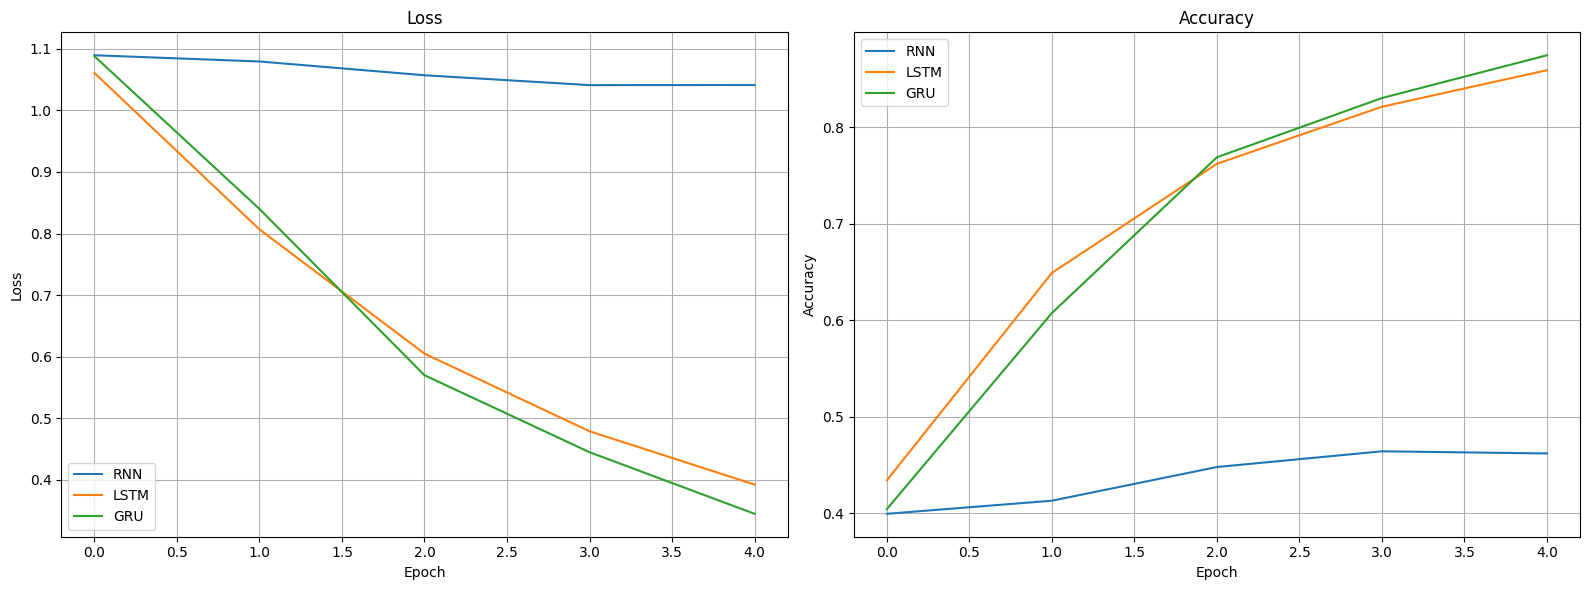

In [60]:
plt.figure(figsize=(16,6))

# Loss
plt.subplot(1,2,1)
plt.plot(hist_rnn.history['loss'], label="RNN")
plt.plot(hist_lstm.history['loss'], label="LSTM")
plt.plot(hist_gru.history['loss'], label="GRU")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(hist_rnn.history['accuracy'], label="RNN")
plt.plot(hist_lstm.history['accuracy'], label="LSTM")
plt.plot(hist_gru.history['accuracy'], label="GRU")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()